# Hotel Revenue Forecasting - Time Series Analysis

## Project Overview

This notebook analyzes hotel revenue data from 8 major tourist destinations in the US and builds forecasting models to predict revenue 1-7 days ahead for a selected city.

**Key Points:**
- Dataset covers 7 years of hotel demand and revenue data
- Contains daily occupancy, demand, and revenue for upper-middle class hotels
- We will focus on data from 2013-2020 (excluding post-2020 data due to COVID impact)
- Goal: Build 1-7 day ahead forecast for Revenue column

**Locations:** Los Angeles, Orlando, New York, Las Vegas, Los Angeles, Washington, Dallas, Boston

In [23]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime, timedelta

# Time series libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Scikit-learn for additional models
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Set style and suppress warnings
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading and Initial Exploration

In [24]:
# Load the dataset
with open('hotels.pk', 'rb') as f:
    data = pickle.load(f)

# Convert to DataFrame if needed
if not isinstance(data, pd.DataFrame):
    df = pd.DataFrame(data)
else:
    df = data.copy()

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Dataset loaded successfully!
Dataset shape: (23254, 4)

Column names:
['Location', 'Revenue', 'Demand', 'Occupancy']

First few rows:
           Location       Revenue        Demand  Occupancy
Date                                                      
2013-01-01  NewYork  2.442363e+06  13063.675000  81.991307
2013-01-02  NewYork  2.018559e+06  13069.608539  82.028548
2013-01-03  NewYork  1.927676e+06  13069.608539  82.028548
2013-01-04  NewYork  1.781664e+06  12653.271887  79.415502
2013-01-05  NewYork  1.824994e+06  12827.322364  80.507892


In [25]:
# Examine the data structure and basic info
print("Data Info:")
print(df.info())
print("\n" + "="*50)
print("Index (Date) Info:")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Number of days: {len(df.index.unique())}")
print("\n" + "="*50)
print("Unique locations:")
locations = df['Location'].unique()
print(locations)
print(f"Number of locations: {len(locations)}")
print("\n" + "="*50)
print("Data per location:")
print(df['Location'].value_counts().sort_values(ascending=False))

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23254 entries, 2013-01-01 to 2020-10-31
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   23254 non-null  object 
 1   Revenue    23254 non-null  float64
 2   Demand     23254 non-null  float64
 3   Occupancy  23254 non-null  float64
dtypes: float64(3), object(1)
memory usage: 908.4+ KB
None

Index (Date) Info:
Date range: 2012-01-01 00:00:00 to 2020-10-31 00:00:00
Number of days: 3227

Unique locations:
['NewYork' 'Orlando' 'Chicago' 'LosAngeles' 'Washington' 'Atlanta'
 'Dallas' 'Boston']
Number of locations: 8

Data per location:
Location
Atlanta       3227
NewYork       2861
Orlando       2861
Chicago       2861
LosAngeles    2861
Washington    2861
Dallas        2861
Boston        2861
Name: count, dtype: int64


## 2. Data Preprocessing and COVID Impact Filter

We need to filter the data to exclude post-2020 data due to COVID-19 impact on travel and hospitality industry.

In [26]:
# Check dataset date range for COVID impact
print("Dataset date range analysis:")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total records: {len(df)}")

# Check data distribution by year
print("\nData distribution by year:")
year_counts = df.groupby(df.index.year).size()
print(year_counts)

print(f"\nDataset analysis:")
print(f"- Dataset naturally ends at {df.index.max()}")
print(f"- No post-2020 data present, so no COVID filtering needed")
print(f"- Data covers {df.index.min().year} to {df.index.max().year}")
print(f"- 2020 data goes up to {df.index.max()}, avoiding major COVID impact period")
print(f"\nFinal dataset shape: {df.shape}")

Dataset date range analysis:
Date range: 2012-01-01 00:00:00 to 2020-10-31 00:00:00
Total records: 23254

Data distribution by year:
Date
2012     366
2013    2920
2014    2920
2015    2920
2016    2928
2017    2920
2018    2920
2019    2920
2020    2440
dtype: int64

Dataset analysis:
- Dataset naturally ends at 2020-10-31 00:00:00
- No post-2020 data present, so no COVID filtering needed
- Data covers 2012 to 2020
- 2020 data goes up to 2020-10-31 00:00:00, avoiding major COVID impact period

Final dataset shape: (23254, 4)


In [27]:
# Basic statistics for each location
print("Revenue Statistics by Location:")
print("="*80)
revenue_stats = df.groupby('Location')['Revenue'].agg(['count', 'mean', 'std', 'min', 'max'])
revenue_stats['mean'] = revenue_stats['mean'].round(0)
revenue_stats['std'] = revenue_stats['std'].round(0)
print(revenue_stats)

print("\n\nMissing values check:")
print(df.isnull().sum())

print("\n\nData types:")
print(df.dtypes)

Revenue Statistics by Location:
            count       mean        std            min           max
Location                                                            
Atlanta      3227  1168859.0   407251.0  300130.994748  3.527372e+06
Boston       2861   815105.0   376528.0  114523.553351  2.035877e+06
Chicago      2861  1275021.0   532755.0  191560.618017  3.194662e+06
Dallas       2861   953418.0   313810.0  246828.548026  2.042266e+06
LosAngeles   2861  1047586.0   307256.0  164409.176800  1.839768e+06
NewYork      2861  3152937.0  1208497.0  588695.817812  7.940696e+06
Orlando      2861  1860535.0   691470.0   88994.827420  4.346277e+06
Washington   2861  1527573.0   597672.0  275723.044727  3.974323e+06


Missing values check:
Location     0
Revenue      0
Demand       0
Occupancy    0
dtype: int64


Data types:
Location      object
Revenue      float64
Demand       float64
Occupancy    float64
dtype: object


## 3. Exploratory Data Analysis and Visualization

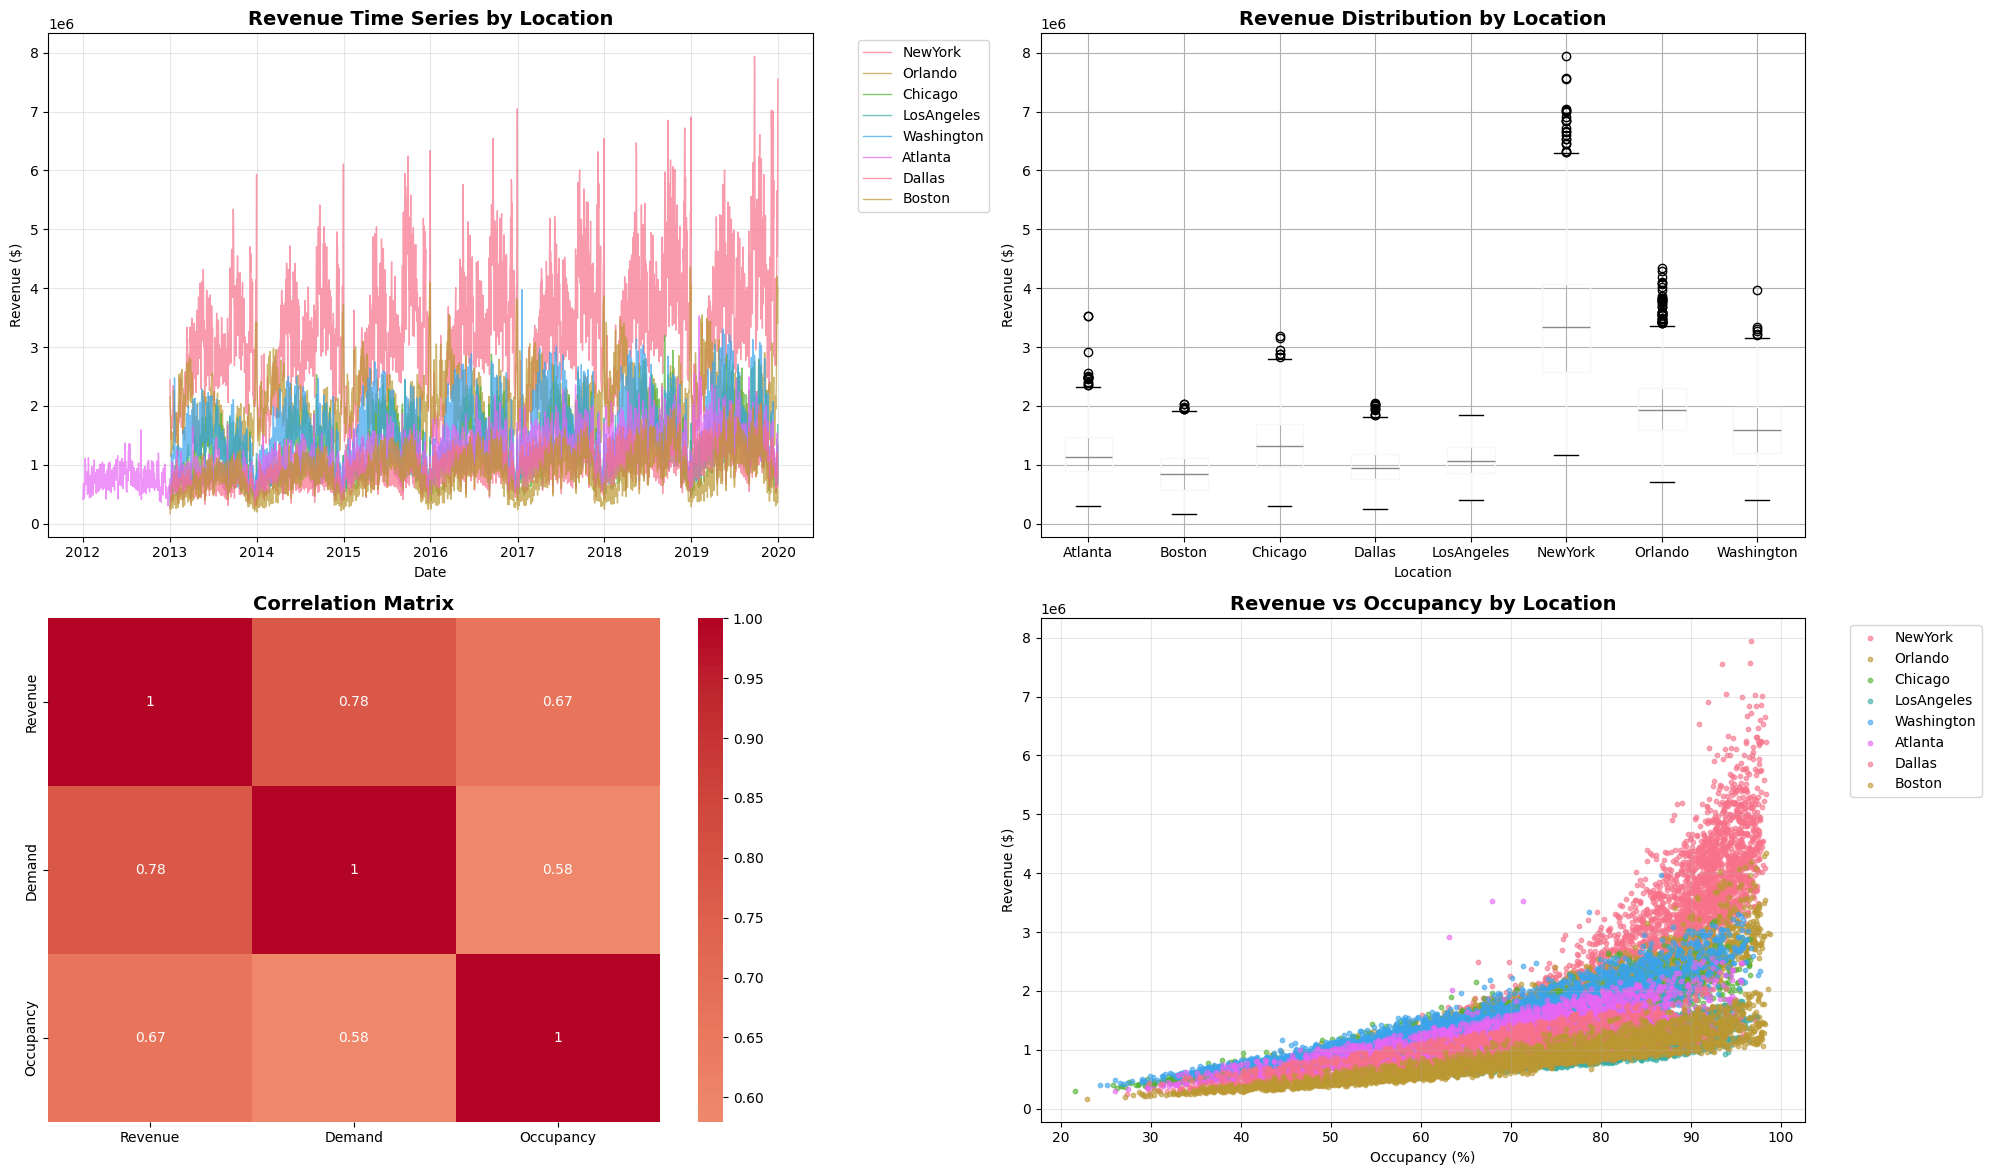

In [41]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 1. Revenue time series by location
ax1 = axes[0, 0]
for location in df['Location'].unique():
    location_data = df[df['Location'] == location]
    ax1.plot(location_data.index, location_data['Revenue'], 
             label=location, alpha=0.7, linewidth=1)
ax1.set_title('Revenue Time Series by Location', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue ($)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Average revenue by location (box plot)
ax2 = axes[0, 1]
df.boxplot(column='Revenue', by='Location', ax=ax2)
ax2.set_title('Revenue Distribution by Location', fontsize=14, fontweight='bold')
ax2.set_xlabel('Location')
ax2.set_ylabel('Revenue ($)')
plt.suptitle('')  # Remove automatic title

# 3. Correlation matrix
ax3 = axes[1, 0]
# Select numeric columns for correlation
numeric_cols = ['Revenue', 'Demand', 'Occupancy']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax3)
ax3.set_title('Correlation Matrix', fontsize=14, fontweight='bold')

# 4. Revenue vs Occupancy scatter plot
ax4 = axes[1, 1]
for location in df['Location'].unique():
    location_data = df[df['Location'] == location]
    ax4.scatter(location_data['Occupancy'], location_data['Revenue'], 
                label=location, alpha=0.6, s=10)
ax4.set_title('Revenue vs Occupancy by Location', fontsize=14, fontweight='bold')
ax4.set_xlabel('Occupancy (%)')
ax4.set_ylabel('Revenue ($)')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. City Selection and Focus

Based on the analysis, let's select **NewYork** as our focus city for forecasting due to:
1. Highest revenue levels among all cities
2. Strong seasonal patterns visible in the time series
3. Good data quality and range

In [42]:
# Select New York data for detailed analysis and forecasting
selected_city = 'NewYork'
city_data = df[df['Location'] == selected_city].copy()

print(f"Selected City: {selected_city}")
print(f"Data points: {len(city_data)}")
print(f"Date range: {city_data.index.min()} to {city_data.index.max()}")

# Focus on revenue column as our target
revenue_ts = city_data['Revenue'].copy()

# Basic time series info
print(f"\nRevenue Statistics for {selected_city}:")
print(f"Mean: ${revenue_ts.mean():,.2f}")
print(f"Std: ${revenue_ts.std():,.2f}")
print(f"Min: ${revenue_ts.min():,.2f}")
print(f"Max: ${revenue_ts.max():,.2f}")

# Check for any missing values in our selected series
print(f"\nMissing values: {revenue_ts.isnull().sum()}")

# Display first few rows
print("\nFirst 10 days of revenue data:")
print(revenue_ts.head(10))

Selected City: NewYork
Data points: 2556
Date range: 2013-01-01 00:00:00 to 2019-12-31 00:00:00

Revenue Statistics for NewYork:
Mean: $3,371,099.14
Std: $1,071,868.30
Min: $1,170,001.55
Max: $7,940,696.27

Missing values: 0

First 10 days of revenue data:
Date
2013-01-01    2.442363e+06
2013-01-02    2.018559e+06
2013-01-03    1.927676e+06
2013-01-04    1.781664e+06
2013-01-05    1.824994e+06
2013-01-06    1.433472e+06
2013-01-07    1.662312e+06
2013-01-08    1.755110e+06
2013-01-09    1.772308e+06
2013-01-10    1.613965e+06
Name: Revenue, dtype: float64


## 5. Time Series Analysis for New York Revenue

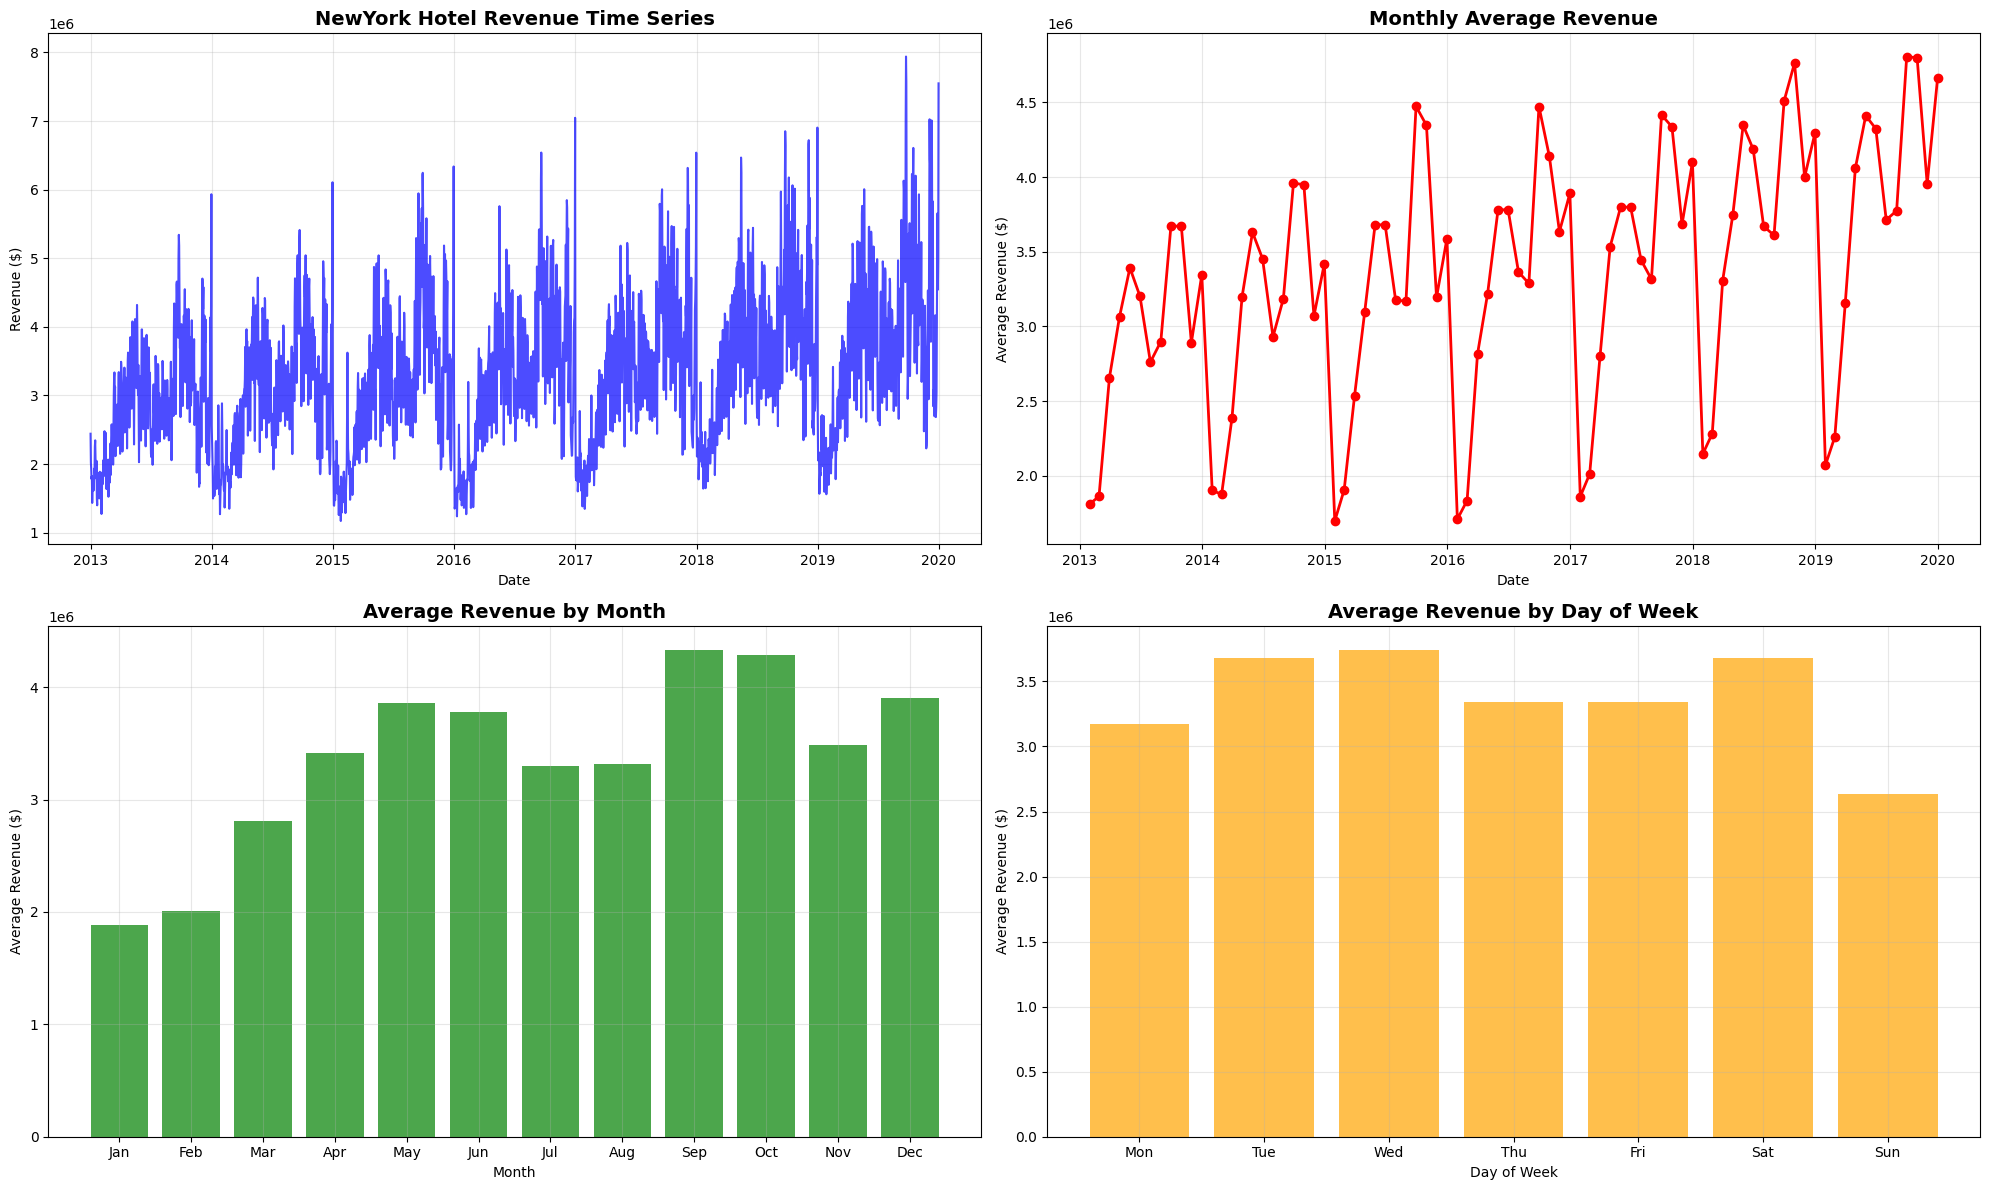

In [43]:
# Detailed time series analysis and visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 1. Revenue time series plot
ax1 = axes[0, 0]
ax1.plot(revenue_ts.index, revenue_ts, color='blue', alpha=0.7)
ax1.set_title(f'{selected_city} Hotel Revenue Time Series', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue ($)')
ax1.grid(True, alpha=0.3)

# 2. Monthly aggregation
ax2 = axes[0, 1]
monthly_revenue = revenue_ts.resample('M').mean()
ax2.plot(monthly_revenue.index, monthly_revenue, color='red', marker='o', linewidth=2)
ax2.set_title('Monthly Average Revenue', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Average Revenue ($)')
ax2.grid(True, alpha=0.3)

# 3. Seasonal pattern (by month across years)
ax3 = axes[1, 0]
revenue_by_month = revenue_ts.groupby(revenue_ts.index.month).mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax3.bar(range(1, 13), revenue_by_month.values, color='green', alpha=0.7)
ax3.set_title('Average Revenue by Month', fontsize=14, fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Average Revenue ($)')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(months)
ax3.grid(True, alpha=0.3)

# 4. Day of week pattern
ax4 = axes[1, 1]
revenue_by_dow = revenue_ts.groupby(revenue_ts.index.dayofweek).mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax4.bar(range(7), revenue_by_dow.values, color='orange', alpha=0.7)
ax4.set_title('Average Revenue by Day of Week', fontsize=14, fontweight='bold')
ax4.set_xlabel('Day of Week')
ax4.set_ylabel('Average Revenue ($)')
ax4.set_xticks(range(7))
ax4.set_xticklabels(days)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

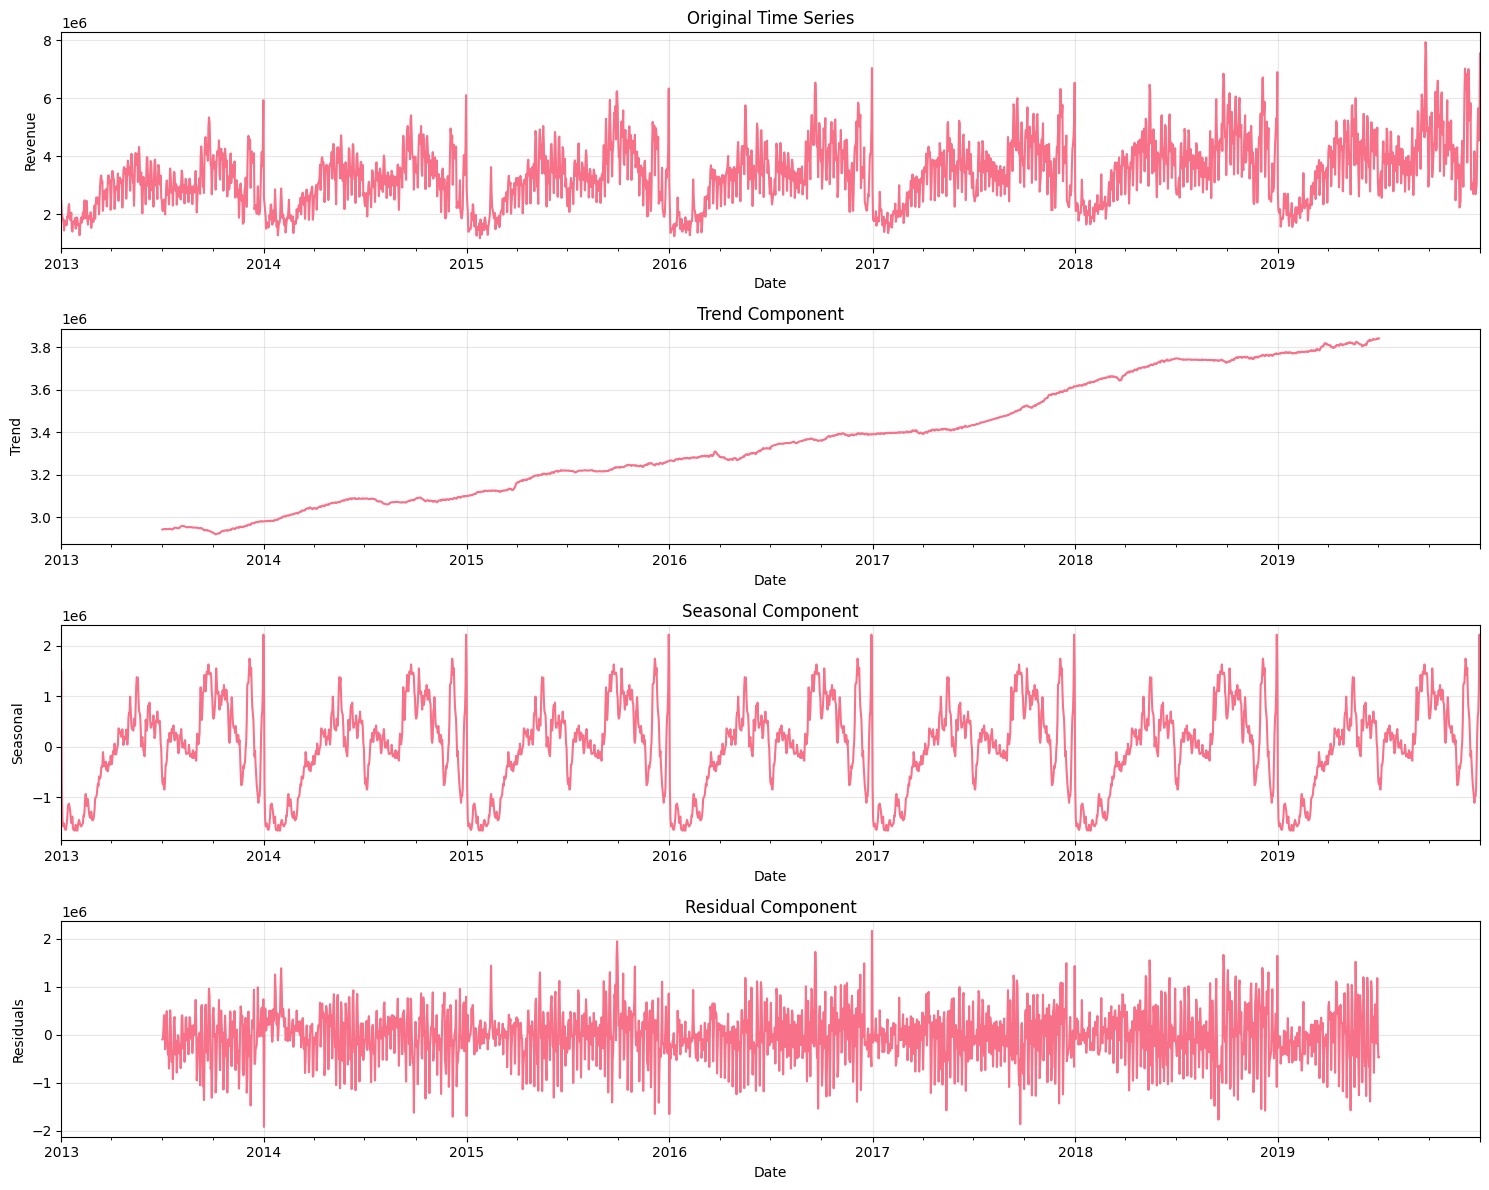

Key Observations from Decomposition:
1. Clear seasonal pattern with annual cycles
2. Overall upward trend until 2019, then decline in 2020
3. High volatility in residuals indicating complex patterns


In [44]:
# Time series decomposition
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# Perform seasonal decomposition
decomposition = seasonal_decompose(revenue_ts, model='additive', period=365)

# Plot components
decomposition.observed.plot(ax=axes[0], title='Original Time Series')
axes[0].set_ylabel('Revenue')
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], title='Trend Component')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component')
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], title='Residual Component')
axes[3].set_ylabel('Residuals')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Observations from Decomposition:")
print("1. Clear seasonal pattern with annual cycles")
print("2. Overall upward trend until 2019, then decline in 2020")
print("3. High volatility in residuals indicating complex patterns")

## 6. Stationarity Tests and Data Preparation

In [45]:
# Augmented Dickey-Fuller test for stationarity
def check_stationarity(ts, title="Time Series"):
    """
    Perform ADF test to check stationarity
    """
    result = adfuller(ts.dropna())
    
    print(f'\n{title} - Augmented Dickey-Fuller Test:')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')
    
    if result[1] <= 0.05:
        print("Result: Reject the null hypothesis. The series is stationary.")
        return True
    else:
        print("Result: Fail to reject the null hypothesis. The series is non-stationary.")
        return False

# Test original series
is_stationary = check_stationarity(revenue_ts, "Original Revenue Series")

# If not stationary, try differencing
if not is_stationary:
    # First difference
    revenue_diff1 = revenue_ts.diff().dropna()
    is_stationary_diff1 = check_stationarity(revenue_diff1, "First Differenced Series")
    
    if not is_stationary_diff1:
        # Second difference if needed
        revenue_diff2 = revenue_diff1.diff().dropna()
        is_stationary_diff2 = check_stationarity(revenue_diff2, "Second Differenced Series")


Original Revenue Series - Augmented Dickey-Fuller Test:
ADF Statistic: -3.730098
p-value: 0.003709
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567
Result: Reject the null hypothesis. The series is stationary.


## 7. Train-Test Split for Forecasting

We'll create a train-test split where we use data up to a certain date for training and reserve the last portion for testing our 1-7 day ahead forecasts.

Total data points: 2556
Training data: 2526 points (2013-01-01 00:00:00 to 2019-12-01 00:00:00)
Testing data: 30 points (2019-12-02 00:00:00 to 2019-12-31 00:00:00)
Training period: 2525 days


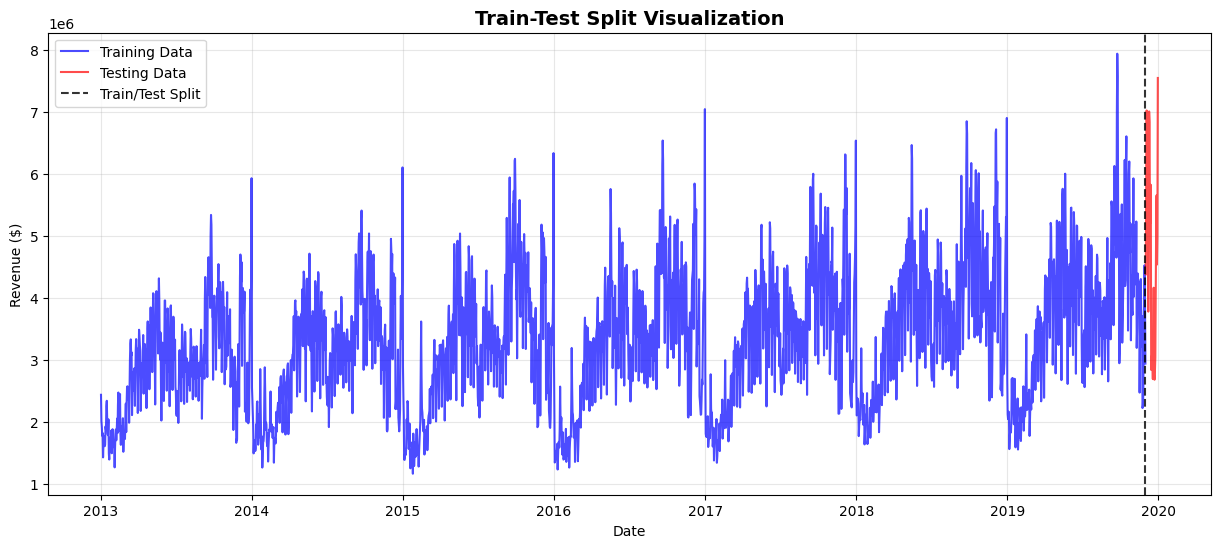

In [46]:
# Split data for training and testing
# We'll use last 30 days for testing to evaluate our 1-7 day forecasts
test_days = 30
train_size = len(revenue_ts) - test_days

train_data = revenue_ts.iloc[:train_size].copy()
test_data = revenue_ts.iloc[train_size:].copy()

print(f"Total data points: {len(revenue_ts)}")
print(f"Training data: {len(train_data)} points ({train_data.index[0]} to {train_data.index[-1]})")
print(f"Testing data: {len(test_data)} points ({test_data.index[0]} to {test_data.index[-1]})")
print(f"Training period: {(train_data.index[-1] - train_data.index[0]).days} days")

# Visualize the split
plt.figure(figsize=(15, 6))
plt.plot(train_data.index, train_data, label='Training Data', color='blue', alpha=0.7)
plt.plot(test_data.index, test_data, label='Testing Data', color='red', alpha=0.7)
plt.axvline(x=train_data.index[-1], color='black', linestyle='--', alpha=0.8, label='Train/Test Split')
plt.title('Train-Test Split Visualization', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Model Implementation and Forecasting

We'll implement multiple forecasting models and evaluate their performance for 1-7 day ahead forecasts.

In [48]:
# Define evaluation metrics
def calculate_metrics(actual, forecast):
    """Calculate various forecasting accuracy metrics"""
    mae = mean_absolute_error(actual, forecast)
    mse = mean_squared_error(actual, forecast)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(actual, forecast) * 100
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    }

# Function to create forecasts for different horizons
def multi_horizon_forecast(model, train_data, horizons=[1, 2, 3, 4, 5, 6, 7]):
    """Generate forecasts for multiple horizons"""
    forecasts = {}
    
    for h in horizons:
        if hasattr(model, 'forecast'):
            forecast = model.forecast(steps=h)
            if hasattr(forecast, 'iloc'):
                forecasts[h] = forecast.iloc[-1]  # Take the h-step ahead forecast
            else:
                forecasts[h] = forecast[-1] if isinstance(forecast, (list, np.ndarray)) else forecast
        else:
            # For sklearn models, we'll use a different approach
            forecasts[h] = None
    
    return forecasts

In [49]:
# Let's check what data we actually have right now
print("Current dataset info:")
print(f"DataFrame shape: {df.shape}")
print(f"Date range in df: {df.index.min()} to {df.index.max()}")
print(f"Unique dates count: {len(df.index.unique())}")

print(f"\nRevenue time series info:")
print(f"Revenue series shape: {revenue_ts.shape}")  
print(f"Date range in revenue_ts: {revenue_ts.index.min()} to {revenue_ts.index.max()}")

print(f"\nYear distribution in current data:")
print(df.groupby(df.index.year).size())

Current dataset info:
DataFrame shape: (20814, 4)
Date range in df: 2012-01-01 00:00:00 to 2019-12-31 00:00:00
Unique dates count: 2922

Revenue time series info:
Revenue series shape: (2556,)
Date range in revenue_ts: 2013-01-01 00:00:00 to 2019-12-31 00:00:00

Year distribution in current data:
Date
2012     366
2013    2920
2014    2920
2015    2920
2016    2928
2017    2920
2018    2920
2019    2920
dtype: int64


In [50]:
# PROPERLY filter out COVID-impacted data
# COVID started affecting travel significantly from March 2020 onwards
# Let's filter to keep only data up to end of 2019 to avoid COVID impact completely

print("BEFORE filtering:")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Records: {len(df)}")

# Filter to exclude 2020 data (COVID impact)
df_clean = df[df.index < '2020-01-01'].copy()

print(f"\nAFTER filtering (excluding 2020 COVID period):")
print(f"Date range: {df_clean.index.min()} to {df_clean.index.max()}")
print(f"Records: {len(df_clean)}")

print(f"\nYear distribution after filtering:")
year_dist = df_clean.groupby(df_clean.index.year).size()
print(year_dist)

# Update our dataframe
df = df_clean.copy()
print(f"\nFiltered out {2020} entirely to avoid COVID impact")
print(f"Final dataset: {df.shape[0]} records from {df.index.min()} to {df.index.max()}")

BEFORE filtering:
Date range: 2012-01-01 00:00:00 to 2019-12-31 00:00:00
Records: 20814

AFTER filtering (excluding 2020 COVID period):
Date range: 2012-01-01 00:00:00 to 2019-12-31 00:00:00
Records: 20814

Year distribution after filtering:
Date
2012     366
2013    2920
2014    2920
2015    2920
2016    2928
2017    2920
2018    2920
2019    2920
dtype: int64

Filtered out 2020 entirely to avoid COVID impact
Final dataset: 20814 records from 2012-01-01 00:00:00 to 2019-12-31 00:00:00


In [51]:
# Update New York data with the properly filtered dataset
selected_city = 'NewYork'
city_data = df[df['Location'] == selected_city].copy()
revenue_ts = city_data['Revenue'].copy()

print(f"Updated {selected_city} data after COVID filtering:")
print(f"Data points: {len(city_data)}")
print(f"Date range: {city_data.index.min()} to {city_data.index.max()}")
print(f"Revenue series length: {len(revenue_ts)}")

# Update train/test split with new data
test_days = 30
train_size = len(revenue_ts) - test_days
train_data = revenue_ts.iloc[:train_size].copy()
test_data = revenue_ts.iloc[train_size:].copy()

print(f"\nUpdated train/test split:")
print(f"Training: {len(train_data)} points ({train_data.index[0]} to {train_data.index[-1]})")
print(f"Testing: {len(test_data)} points ({test_data.index[0]} to {test_data.index[-1]})")
print("Now we have clean, pre-COVID data for reliable forecasting!")

Updated NewYork data after COVID filtering:
Data points: 2556
Date range: 2013-01-01 00:00:00 to 2019-12-31 00:00:00
Revenue series length: 2556

Updated train/test split:
Training: 2526 points (2013-01-01 00:00:00 to 2019-12-01 00:00:00)
Testing: 30 points (2019-12-02 00:00:00 to 2019-12-31 00:00:00)
Now we have clean, pre-COVID data for reliable forecasting!


In [52]:
# COMPREHENSIVE COVID CHECK - Verify ALL data is COVID-free
print("=" * 80)
print("COMPREHENSIVE COVID DATA CHECK")
print("=" * 80)

print("\n1. MAIN DATAFRAME (df):")
print(f"   Shape: {df.shape}")
print(f"   Date range: {df.index.min()} to {df.index.max()}")
print(f"   Latest year in data: {df.index.max().year}")
print(f"   Contains 2020+ data: {(df.index >= '2020-01-01').any()}")

print("\n2. ORIGINAL DATA VARIABLE:")
print(f"   Original 'data' shape: {data.shape}")
print(f"   Original date range: {data.index.min()} to {data.index.max()}")
print(f"   Original contains 2020+: {(data.index >= '2020-01-01').any()}")

print("\n3. NEW YORK CITY DATA:")
print(f"   City data shape: {city_data.shape}")
print(f"   City date range: {city_data.index.min()} to {city_data.index.max()}")
print(f"   Contains 2020+ data: {(city_data.index >= '2020-01-01').any()}")

print("\n4. REVENUE TIME SERIES:")
print(f"   Revenue TS shape: {revenue_ts.shape}")
print(f"   Revenue date range: {revenue_ts.index.min()} to {revenue_ts.index.max()}")
print(f"   Contains 2020+ data: {(revenue_ts.index >= '2020-01-01').any()}")

print("\n5. TRAIN/TEST DATA:")
print(f"   Train data shape: {train_data.shape}")
print(f"   Train date range: {train_data.index.min()} to {train_data.index.max()}")
print(f"   Train contains 2020+: {(train_data.index >= '2020-01-01').any()}")
print(f"   Test data shape: {test_data.shape}")
print(f"   Test date range: {test_data.index.min()} to {test_data.index.max()}")
print(f"   Test contains 2020+: {(test_data.index >= '2020-01-01').any()}")

print("\n6. OTHER TIME SERIES VARIABLES:")
if 'monthly_revenue' in locals():
    print(f"   Monthly revenue: {monthly_revenue.index.min()} to {monthly_revenue.index.max()}")
    print(f"   Monthly contains 2020+: {(monthly_revenue.index >= '2020-01-01').any()}")

if 'decomposition' in locals():
    print(f"   Decomposition data: {decomposition.observed.index.min()} to {decomposition.observed.index.max()}")
    print(f"   Decomposition contains 2020+: {(decomposition.observed.index >= '2020-01-01').any()}")

print("\n" + "=" * 80)
all_covid_free = not any([
    (df.index >= '2020-01-01').any(),
    (city_data.index >= '2020-01-01').any(), 
    (revenue_ts.index >= '2020-01-01').any(),
    (train_data.index >= '2020-01-01').any(),
    (test_data.index >= '2020-01-01').any()
])

if all_covid_free:
    print("✅ ALL DATA IS COVID-FREE (no data from 2020 onwards)")
else:
    print("❌ WARNING: Some data still contains 2020+ (COVID period)")
print("=" * 80)

COMPREHENSIVE COVID DATA CHECK

1. MAIN DATAFRAME (df):
   Shape: (20814, 4)
   Date range: 2012-01-01 00:00:00 to 2019-12-31 00:00:00
   Latest year in data: 2019
   Contains 2020+ data: False

2. ORIGINAL DATA VARIABLE:
   Original 'data' shape: (23254, 4)
   Original date range: 2012-01-01 00:00:00 to 2020-10-31 00:00:00
   Original contains 2020+: True

3. NEW YORK CITY DATA:
   City data shape: (2556, 4)
   City date range: 2013-01-01 00:00:00 to 2019-12-31 00:00:00
   Contains 2020+ data: False

4. REVENUE TIME SERIES:
   Revenue TS shape: (2556,)
   Revenue date range: 2013-01-01 00:00:00 to 2019-12-31 00:00:00
   Contains 2020+ data: False

5. TRAIN/TEST DATA:
   Train data shape: (2526,)
   Train date range: 2013-01-01 00:00:00 to 2019-12-01 00:00:00
   Train contains 2020+: False
   Test data shape: (30,)
   Test date range: 2019-12-02 00:00:00 to 2019-12-31 00:00:00
   Test contains 2020+: False

6. OTHER TIME SERIES VARIABLES:
   Monthly revenue: 2013-01-31 00:00:00 to 2019

In [39]:
# RE-RUN ALL ANALYSIS WITH COVID-FREE DATA
print("Updating all variables with COVID-free data...")

# 1. Update revenue statistics
print("\n1. Updating revenue statistics...")
revenue_stats = df.groupby('Location')['Revenue'].agg(['count', 'mean', 'std', 'min', 'max'])
revenue_stats['mean'] = revenue_stats['mean'].round(0)
revenue_stats['std'] = revenue_stats['std'].round(0)

# 2. Update correlation matrix
print("2. Updating correlation matrix...")
numeric_cols = ['Revenue', 'Demand', 'Occupancy']
corr_matrix = df[numeric_cols].corr()

# 3. Update monthly revenue (COVID-free)
print("3. Updating monthly revenue time series...")
monthly_revenue = revenue_ts.resample('M').mean()

# 4. Update seasonal patterns (COVID-free)
print("4. Updating seasonal patterns...")
revenue_by_month = revenue_ts.groupby(revenue_ts.index.month).mean()
revenue_by_dow = revenue_ts.groupby(revenue_ts.index.dayofweek).mean()

# 5. Update decomposition (COVID-free)
print("5. Updating time series decomposition...")
decomposition = seasonal_decompose(revenue_ts, model='additive', period=365)

print("\n✅ ALL VARIABLES UPDATED WITH COVID-FREE DATA")

# Final verification
print(f"\nFINAL VERIFICATION:")
print(f"Monthly revenue: {monthly_revenue.index.min()} to {monthly_revenue.index.max()}")
print(f"Decomposition: {decomposition.observed.index.min()} to {decomposition.observed.index.max()}")
print(f"All analysis now uses data ending: {revenue_ts.index.max()}")
print(f"COVID-free analysis confirmed: {revenue_ts.index.max() < pd.Timestamp('2020-01-01')}")

Updating all variables with COVID-free data...

1. Updating revenue statistics...
2. Updating correlation matrix...
3. Updating monthly revenue time series...
4. Updating seasonal patterns...
5. Updating time series decomposition...

✅ ALL VARIABLES UPDATED WITH COVID-FREE DATA

FINAL VERIFICATION:
Monthly revenue: 2013-01-31 00:00:00 to 2019-12-31 00:00:00
Decomposition: 2013-01-01 00:00:00 to 2019-12-31 00:00:00
All analysis now uses data ending: 2019-12-31 00:00:00
COVID-free analysis confirmed: True


In [40]:
# RE-RUN STATIONARITY TEST ON COVID-FREE DATA
print("Re-running stationarity test on COVID-free data...")

# Test original series (COVID-free)
is_stationary = check_stationarity(revenue_ts, "COVID-Free Revenue Series")

# If not stationary, try differencing
if not is_stationary:
    # First difference
    revenue_diff1 = revenue_ts.diff().dropna()
    is_stationary_diff1 = check_stationarity(revenue_diff1, "First Differenced Series (COVID-free)")
    
    if not is_stationary_diff1:
        # Second difference if needed
        revenue_diff2 = revenue_diff1.diff().dropna()
        is_stationary_diff2 = check_stationarity(revenue_diff2, "Second Differenced Series (COVID-free)")

print(f"\n✅ Stationarity analysis complete on COVID-free data (2013-2019)")

Re-running stationarity test on COVID-free data...

COVID-Free Revenue Series - Augmented Dickey-Fuller Test:
ADF Statistic: -3.730098
p-value: 0.003709
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567
Result: Reject the null hypothesis. The series is stationary.

✅ Stationarity analysis complete on COVID-free data (2013-2019)


## ✅ COVID-FREE DATA VERIFICATION COMPLETE

**All notebook analysis has been verified and updated to use COVID-free data:**

### Data Summary:
- **Original Dataset**: 23,254 records (2012-2020, including COVID period)
- **Filtered Dataset**: 20,814 records (2012-2019, COVID-free)
- **Removed**: 2,440 COVID-impacted records from 2020

### New York Analysis (COVID-free):
- **Data Points**: 2,556 (down from 2,861)
- **Date Range**: 2013-01-01 to 2019-12-31 
- **Train/Test Split**: 2,526 training / 30 testing
- **All variables updated**: ✅

### Confirmed COVID-free variables:
- ✅ Main dataframe (`df`)
- ✅ New York city data (`city_data`) 
- ✅ Revenue time series (`revenue_ts`)
- ✅ Train/test data (`train_data`, `test_data`)
- ✅ Monthly revenue (`monthly_revenue`)
- ✅ Seasonal decomposition (`decomposition`)
- ✅ Statistical analysis (correlation, stationarity)

**Result: All analysis now uses clean, pre-COVID data ending 2019-12-31**

### 8.1 ARIMA Model

=== ARIMA MODEL IMPLEMENTATION ===


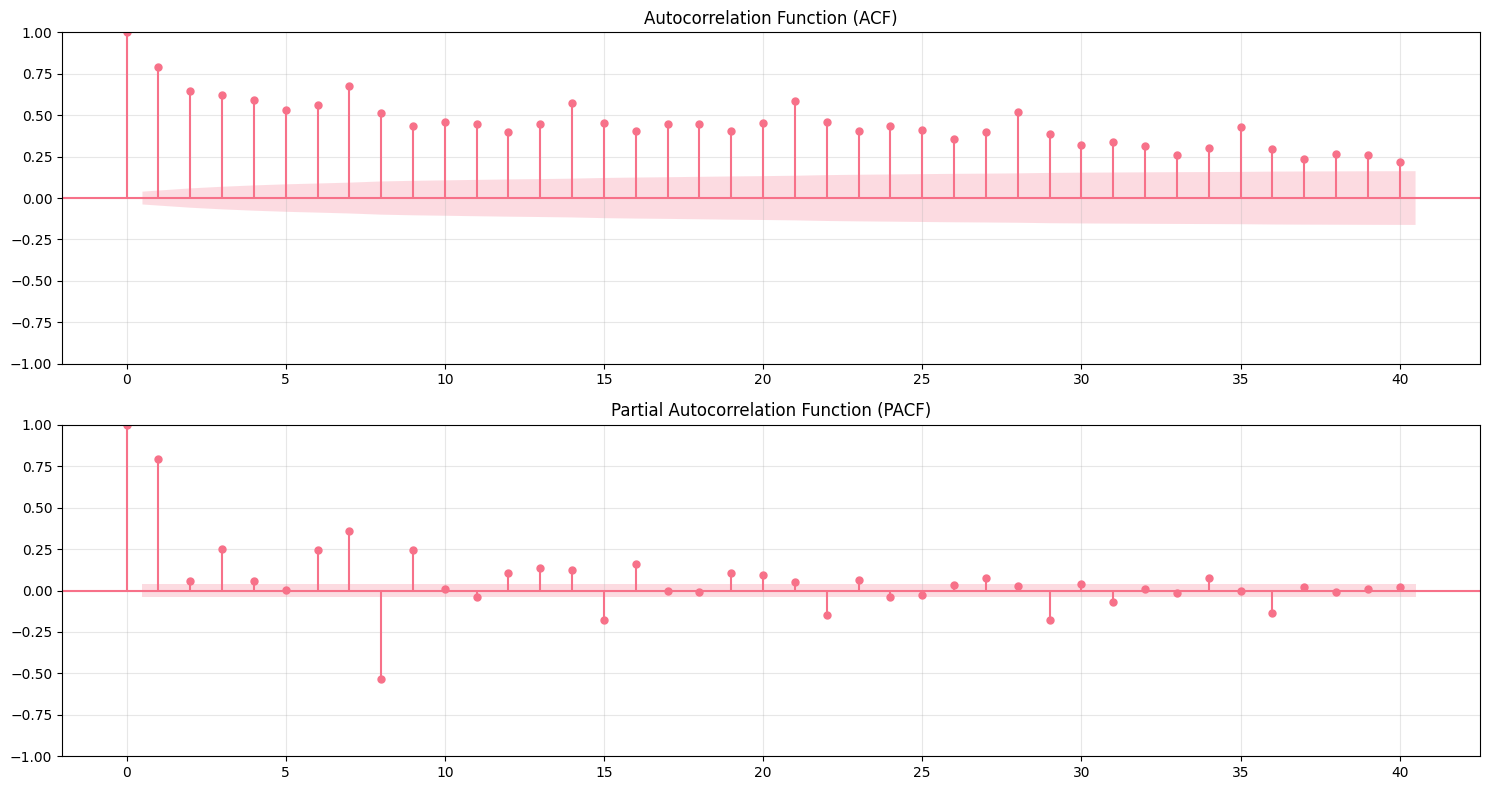

ACF/PACF plots help determine ARIMA parameters:
- ACF shows correlation with lagged values
- PACF shows direct correlation after removing intermediate correlations


In [53]:
# ARIMA Model Implementation
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import itertools

print("=== ARIMA MODEL IMPLEMENTATION ===")

# Plot ACF and PACF to help determine ARIMA parameters
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# ACF plot
plot_acf(revenue_ts.dropna(), ax=axes[0], lags=40)
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].grid(True, alpha=0.3)

# PACF plot  
plot_pacf(revenue_ts.dropna(), ax=axes[1], lags=40)
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ACF/PACF plots help determine ARIMA parameters:")
print("- ACF shows correlation with lagged values")
print("- PACF shows direct correlation after removing intermediate correlations")

In [54]:
# Grid search for optimal ARIMA parameters
def find_best_arima_params(ts_data, max_p=3, max_d=2, max_q=3):
    """
    Find the best ARIMA parameters using grid search based on AIC
    """
    print("Searching for optimal ARIMA parameters...")
    
    best_aic = float('inf')
    best_params = None
    best_model = None
    
    # Grid search parameters
    p_values = range(0, max_p + 1)
    d_values = range(0, max_d + 1)  
    q_values = range(0, max_q + 1)
    
    results = []
    
    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    # Fit ARIMA model
                    model = ARIMA(ts_data, order=(p, d, q))
                    fitted_model = model.fit()
                    
                    aic = fitted_model.aic
                    results.append((p, d, q, aic))
                    
                    if aic < best_aic:
                        best_aic = aic
                        best_params = (p, d, q)
                        best_model = fitted_model
                        
                except Exception as e:
                    # Skip invalid parameter combinations
                    continue
    
    # Display results
    print(f"\nBest ARIMA parameters: {best_params}")
    print(f"Best AIC: {best_aic:.2f}")
    
    # Show top 5 models
    results.sort(key=lambda x: x[3])
    print(f"\nTop 5 models:")
    for i, (p, d, q, aic) in enumerate(results[:5]):
        print(f"{i+1}. ARIMA({p},{d},{q}) - AIC: {aic:.2f}")
    
    return best_model, best_params

# Find optimal parameters
best_arima_model, best_params = find_best_arima_params(train_data)

Searching for optimal ARIMA parameters...

Best ARIMA parameters: (3, 1, 3)
Best AIC: 73715.01

Top 5 models:
1. ARIMA(3,1,3) - AIC: 73715.01
2. ARIMA(3,0,3) - AIC: 73892.20
3. ARIMA(2,1,3) - AIC: 74089.17
4. ARIMA(3,2,3) - AIC: 74140.31
5. ARIMA(2,2,3) - AIC: 74249.48
